<a href="https://colab.research.google.com/github/MulukenChernetET/OIBSIP/blob/main/DataAnalytics-L1-EDARetailSales/eda_retail_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Superstore sales dataset (1).txt to Superstore sales dataset (1).txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Superstore sales dataset (1).txt', encoding='latin1')

# First look
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df. H

In [ ]:
# How many rows and columns?
print("Shape (rows, columns):", df.shape)

# What are the column names and data types?
print("\nColumn info:")
df.info()

# Are there any missing values?
print("\nMissing values per column:")
print(df.isnull().sum())

Shape (rows, columns): (9994, 21)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ï»¿Row ID      9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sale

In [ ]:
# Clean up column names (remove any hidden BOM characters, extra spaces)
df.columns = df.columns.str.strip().str.replace('ï»¿', '', regex=False)

# Confirm the fix
print(df.columns.tolist())

# Convert Order Date and Ship Date from text to actual datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

# Confirm the conversion worked
print(df[['Order Date', 'Ship Date']].dtypes)

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
# Descriptive statistics for numerical columns
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


Observation: The average order value is about $230, but the standard deviation ($623) is much larger than the mean, showing the data is highly spread out. The median order value is only $54.49, far below the mean, which tells us most orders are small, while a handful of very large orders (up to $22,638) are pulling the average upward. This suggests the business relies on a mix of frequent small purchases and occasional bulk/high-value orders.

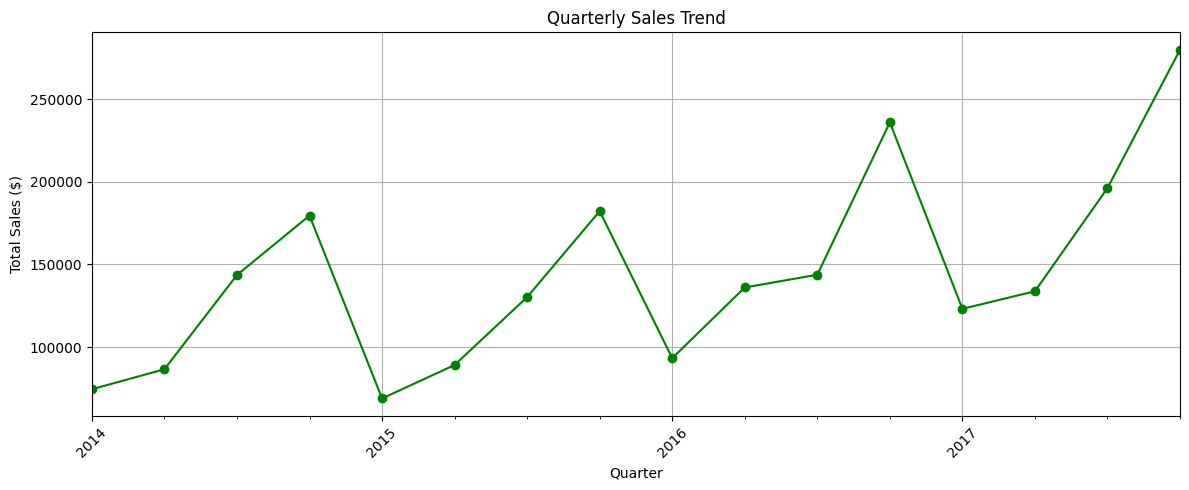

In [ ]:
# Create a quarter column
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')

# Group sales by quarter
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

# Plot quarterly sales trend
plt.figure(figsize=(12,5))
quarterly_sales.plot(kind='line', marker='o', color='green')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: Sales show a clear upward trend from 2014 to 2017, with the business roughly tripling its quarterly peak sales over this period. There is also a recurring seasonal pattern: sales dip every Q1 (January-March) and rise sharply in Q3-Q4, suggesting stronger demand in the second half of each year. This seasonality should inform inventory and staffing decisions ahead of the busier quarters.

<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_10620/248871526.py:18: SyntaxWarning: invalid escape sequence '\$'
  axes[1].set_ylabel('Total Sales (\$)')


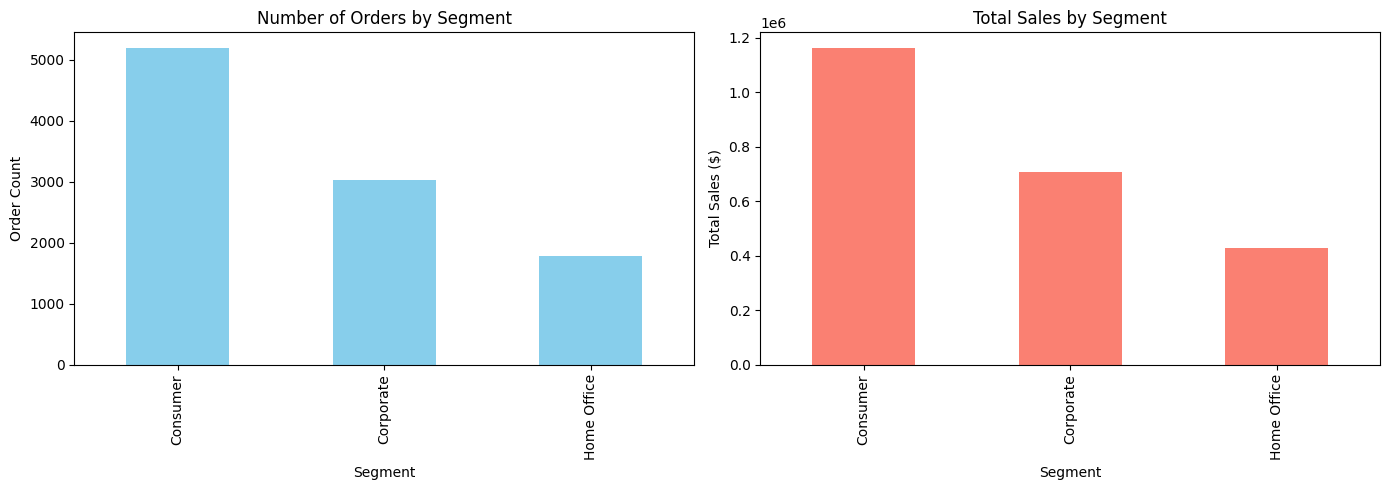

In [ ]:
# Count of orders by customer segment
segment_counts = df['Segment'].value_counts()

# Total sales by segment
segment_sales = df.groupby('Segment')['Sales'].sum()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

segment_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Number of Orders by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Order Count')

segment_sales.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Total Sales by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Sales (\$)')

plt.tight_layout()
plt.show()

Observation: The graph shows that the Consumer segment holds the majority of both orders and sales, followed by Corporate, with Home Office contributing the least. Interestingly, the ranking is the same for both order count and sales value meaning no single segment is disproportionately driving revenue relative to its order volume.

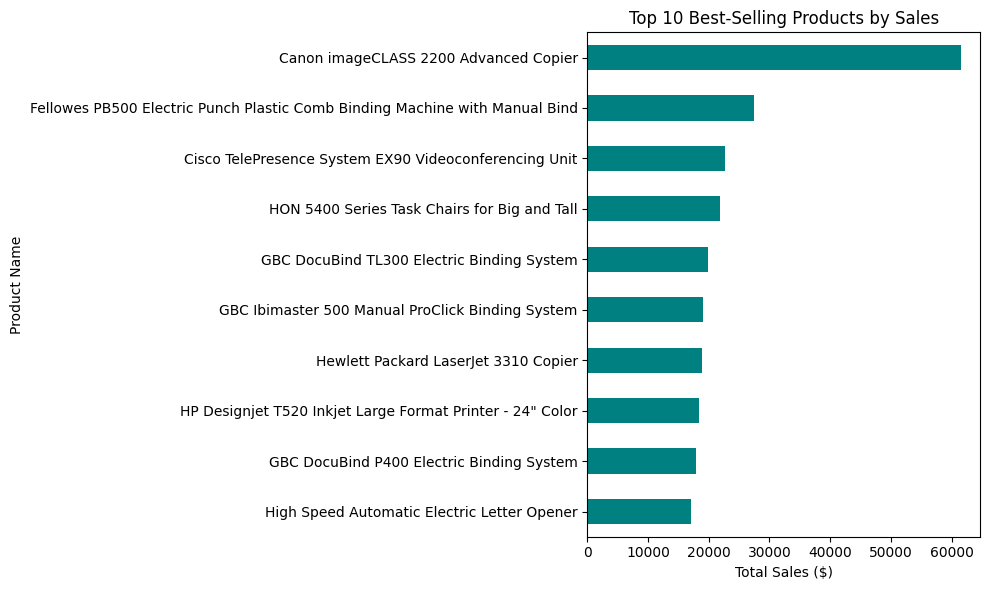

In [ ]:
# Top 10 best-selling products by total sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='teal')
plt.title('Top 10 Best-Selling Products by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()  # highest value on top
plt.tight_layout()
plt.show()

Observation: The Canon imageCLASS 2200 Advanced Copier is the top selling product, generating close to $60,000 in sales, followed by the Fellowes PB500 Electric Punch Plastic Comb Binding Machine. The lowest performer in the top 10 was the High Speed Automatic Electric Letter Opener. Notably, most of the top 10 products are office equipment (copiers, binding machines, printers) rather than everyday office supplies, suggesting big ticket equipment purchases drive a large share of revenue despite being ordered less frequently.

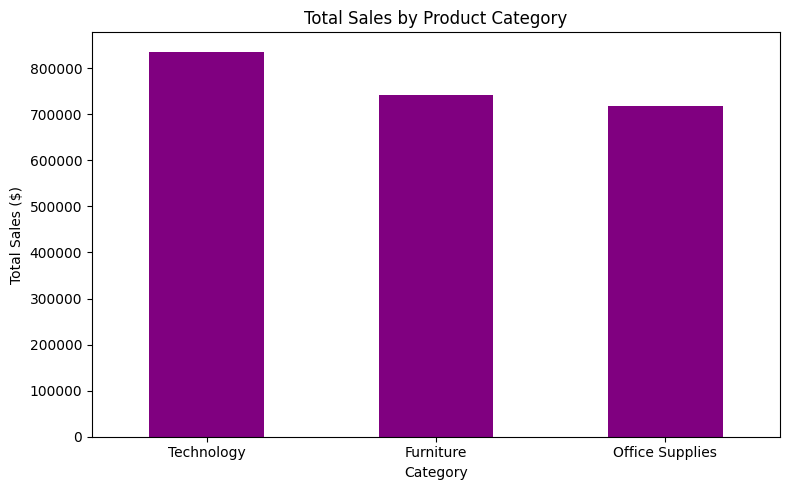

In [ ]:
# Total sales by product category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='purple')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Observation: Technology generates the highest total sales, followed closely by Furniture and Office Supplies, all within a similar range (roughly $700K-$830K). Unlike the product-level chart, no single category dominates disproportionately  revenue is fairly evenly distributed across the three categories, suggesting the business has a balanced, diversified product mix rather than depending heavily on one category.

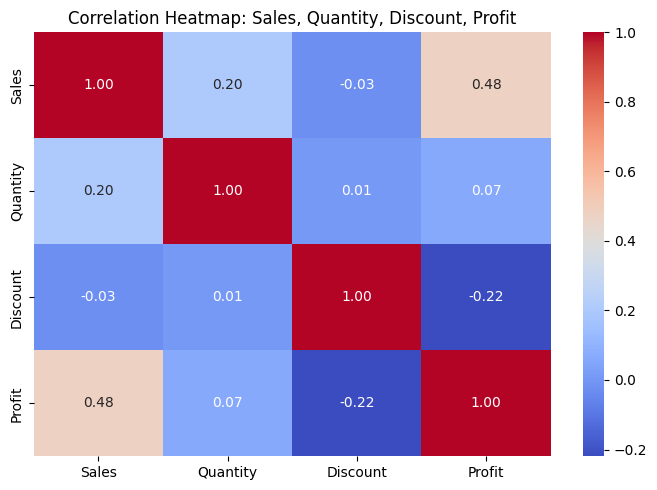

In [ ]:
# Correlation matrix of key numeric columns
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.show()

Observation: Profit shows a moderate positive correlation with Sales (0.48), meaning higher sales generally translate into higher profit, though not perfectly. More notably, Discount has a negative correlation with Profit (-0.22) but almost no correlation with Sales (-0.03) suggesting that discounts are eroding profit margins without meaningfully driving additional sales volume. This implies the business may benefit from reviewing its discounting strategy, since discounts appear to be a cost without a clear sales-boosting effect.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Superstore sales dataset (1).txt', encoding='latin1')

# First look
df.head()

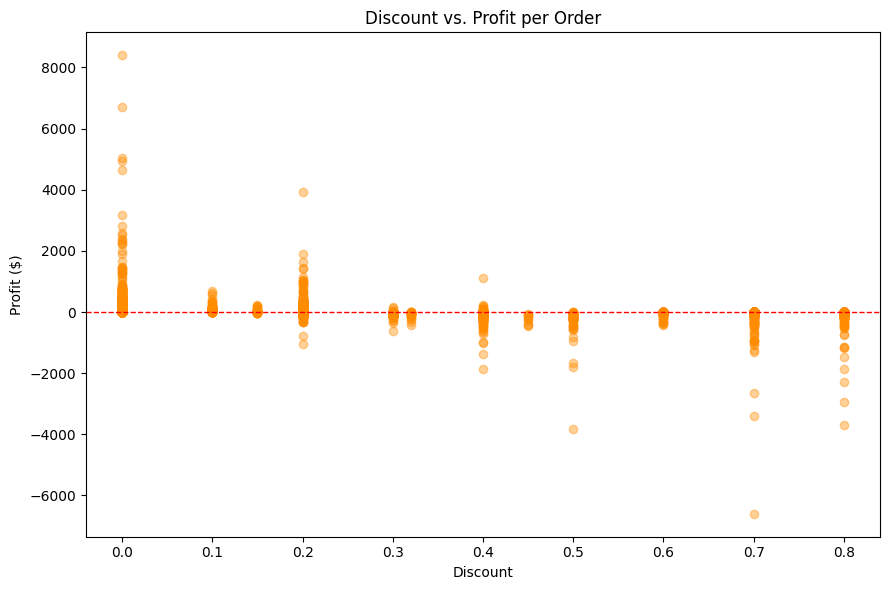

In [ ]:
plt.figure(figsize=(9,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.4, color='darkorange')
plt.title('Discount vs. Profit per Order')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

Observation: This scatter plot makes the earlier correlation concrete: orders with no or low discount show a wide range of profits, many strongly positive. However, once discounts exceed roughly 30-40%, the vast majority of orders fall below the zero profit line, and by 70-80% discount, nearly every order results in a loss. This strongly suggests that discounts above ~30% are, in most cases, unprofitable and should be reviewed or capped as part of pricing strategy.

## Conclusion: Key Business Recommendations

1.**Cap deep discounts.** Orders discounted above ~30-40% are frequently unprofitable, with losses growing sharply as discount increases. The business should review or restrict discounting beyond this threshold, since it does not correspond to meaningfully higher sales volume.

2. **Prepare inventory and staffing for Q3-Q4 demand.** Sales show a consistent seasonal pattern, dipping in Q1 and rising sharply in the second half of the year. Proactively scaling inventory and staffing ahead of Q3 could capture more of this demand and avoid stockouts during peak season.

3. **Continue promoting high-value equipment alongside frequent small purchases.** While most orders are small (median ~\$54), big-ticket technology and equipment items (like copiers and binding machines) contribute disproportionately to revenue. Bundling smaller accessories with these high-value items could increase average order value without needing additional discounting.